# Enviroment Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !!! ACTION REQUIRED !!! - update paths for your project structure

DRIVE_PATH = 'YOUR_PATH'

RES_DIR = f'{DRIVE_PATH}/05_prediction_results'
VIS_DIR = f'{DRIVE_PATH}/03_visualizations/Results'

# Results Load

In [4]:
sarima_df = pd.read_csv(os.path.join(RES_DIR, 'sarima_results.csv'))
xgb_df = pd.read_csv(os.path.join(RES_DIR, 'xgboost_results.csv'))
lstm_df = pd.read_csv(os.path.join(RES_DIR, 'lstm_results.csv'))
rf_df = pd.read_csv(os.path.join(RES_DIR, 'rf_results.csv'))
prophet_df = pd.read_csv(os.path.join(RES_DIR, 'prophet_results.csv'))

sarima_df['model'] = 'SARIMA'
xgb_df['model'] = 'XGBoost'
lstm_df['model'] = 'LSTM'
rf_df['model'] = 'RF'
prophet_df['model'] = 'Prophet'

all_results = pd.concat([sarima_df, xgb_df, lstm_df, rf_df, prophet_df], ignore_index=True)

print(f"Loaded results: {len(sarima_df)} SARIMA + {len(xgb_df)} XGBoost + {len(lstm_df)} LSTM + {len(rf_df)} RF + {len(prophet_df)} Prophet")
print(f"Total: {len(all_results)} entries")

Loaded results: 6 SARIMA + 6 XGBoost + 6 LSTM + 6 RF + 6 Prophet
Total: 30 entries


# Results Comparison

## Result Table

In [5]:
print("\n" + "=" * 100)
print("COMPLETE MODEL COMPARISON — ALL DATASETS")
print("=" * 100)

# pivot table
for metric in ['mae', 'rmse', 'mape']:
    print(f"\n--- {metric.upper()} ---")
    pivot = all_results.pivot(index='dataset', columns='model', values=metric)
    pivot = pivot[['SARIMA', 'XGBoost', 'LSTM', 'RF', 'Prophet']]

    pivot['Best'] = pivot.idxmin(axis=1)

    print(pivot.to_string())


COMPLETE MODEL COMPARISON — ALL DATASETS

--- MAE ---
model                         SARIMA  XGBoost    LSTM      RF  Prophet     Best
dataset                                                                        
Austin TX (USA)               638.50   138.22  320.94  155.64   202.96  XGBoost
Ballarat (Australia)           24.91    10.56   27.49   10.50    16.99       RF
Boralesgamuwa UC (Sri Lanka)    7.27     5.90    7.89    6.01     7.55  XGBoost
Dehiwala MC (Sri Lanka)        40.75    23.57   41.73   23.50    34.69       RF
Homagama PS (Sri Lanka)        11.16    11.04   12.32   10.75    11.89       RF
Moratuwa MC (Sri Lanka)        19.39    20.06   20.17   19.69    24.57   SARIMA

--- RMSE ---
model                         SARIMA  XGBoost    LSTM      RF  Prophet     Best
dataset                                                                        
Austin TX (USA)               808.34   304.51  496.19  343.90   372.13  XGBoost
Ballarat (Australia)           33.20    16.86   33.

## Model Statistics

In [6]:
print("\n" + "=" * 100)
print("AVERAGE METRICS PER MODEL")
print("=" * 100)

summary = all_results.groupby('model')[['mae', 'rmse', 'mape']].mean()
summary = summary.loc[['SARIMA', 'XGBoost', 'LSTM', 'RF', 'Prophet']]

print(f"\n{'Model':<12s} | {'Avg MAE (t)':>12s} | {'Avg RMSE (t)':>13s} | {'Avg MAPE (%)':>13s}")
print("-" * 60)
for model, row in summary.iterrows():
    print(f"{model:<12s} | {row['mae']:>12.2f} | {row['rmse']:>13.2f} | {row['mape']:>12.2f}%")

best_model = summary['mae'].idxmin()
print(f"\nBest model by average MAE:  {best_model}")
best_model = summary['rmse'].idxmin()
print(f"Best model by average RMSE: {best_model}")
best_model = summary['mape'].idxmin()
print(f"Best model by average MAPE: {best_model}")


AVERAGE METRICS PER MODEL

Model        |  Avg MAE (t) |  Avg RMSE (t) |  Avg MAPE (%)
------------------------------------------------------------
SARIMA       |       123.66 |        156.30 |       286.88%
XGBoost      |        34.89 |         67.05 |        35.43%
LSTM         |        71.76 |        104.85 |       107.95%
RF           |        37.68 |         74.16 |        33.55%
Prophet      |        49.77 |         82.22 |        47.96%

Best model by average MAE:  XGBoost
Best model by average RMSE: XGBoost
Best model by average MAPE: RF


## MAE Comparison

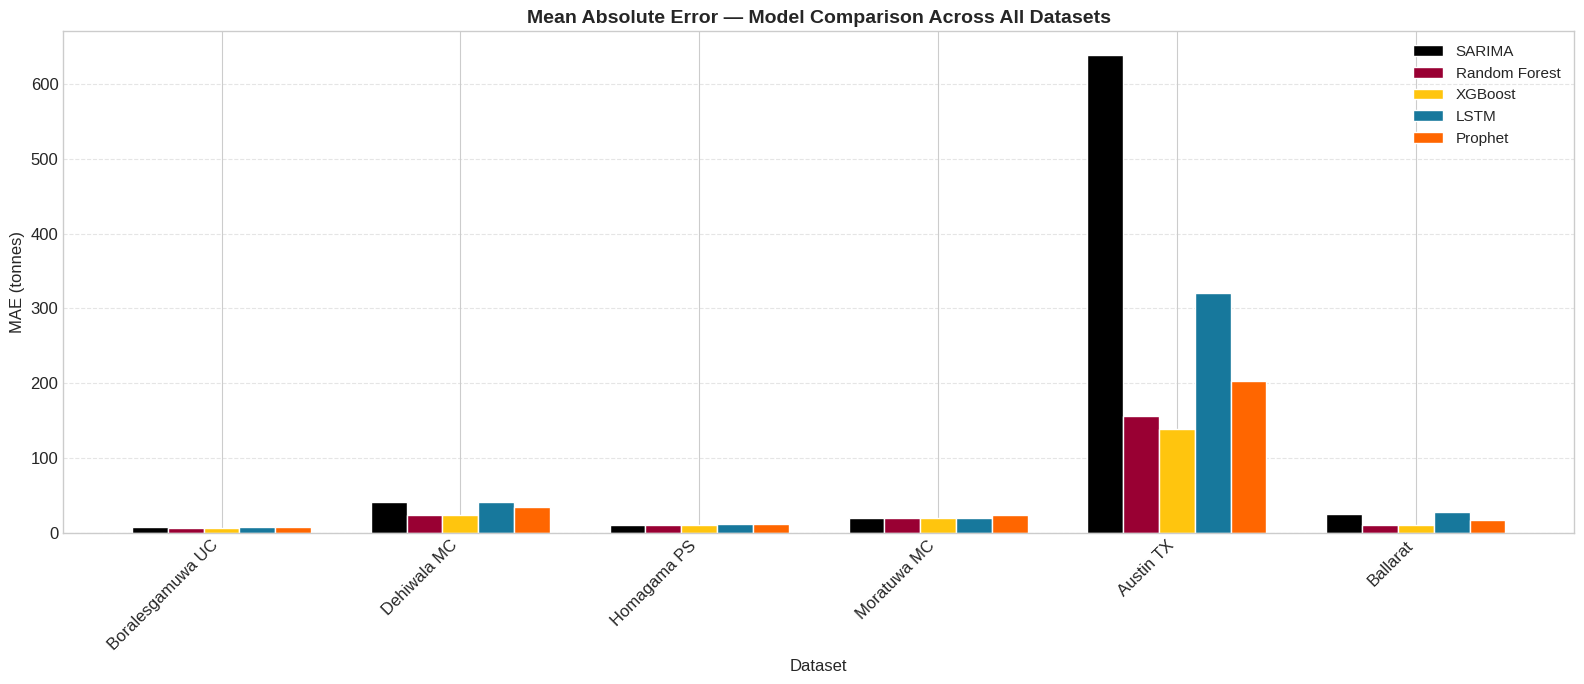

In [7]:
# --- Plot MAE Comparison ---
fig, ax = plt.subplots(figsize=(16, 7))

datasets = sarima_df['dataset'].values
short_names = [d.split('(')[0].strip() for d in datasets]
x = np.arange(len(datasets))
width = 0.15

bars1 = ax.bar(x - 2*width, sarima_df['mae'], width, label='SARIMA', color='#000000', edgecolor='white')
bars2 = ax.bar(x - width, rf_df['mae'], width, label='Random Forest', color='#990033', edgecolor='white')
bars3 = ax.bar(x, xgb_df['mae'], width, label='XGBoost', color='#FFC50E', edgecolor='white')
bars4 = ax.bar(x + width, lstm_df['mae'], width, label='LSTM', color='#17789C', edgecolor='white')
bars5 = ax.bar(x + 2*width, prophet_df['mae'], width, label='Prophet', color='#FF6600', edgecolor='white')

ax.set_xlabel('Dataset', fontsize=12)
ax.set_ylabel('MAE (tonnes)', fontsize=12)
ax.set_title('Mean Absolute Error — Model Comparison Across All Datasets', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, 'comparison_mae_all.png'), dpi=150, bbox_inches='tight')
plt.show()

## RMSE Comparison

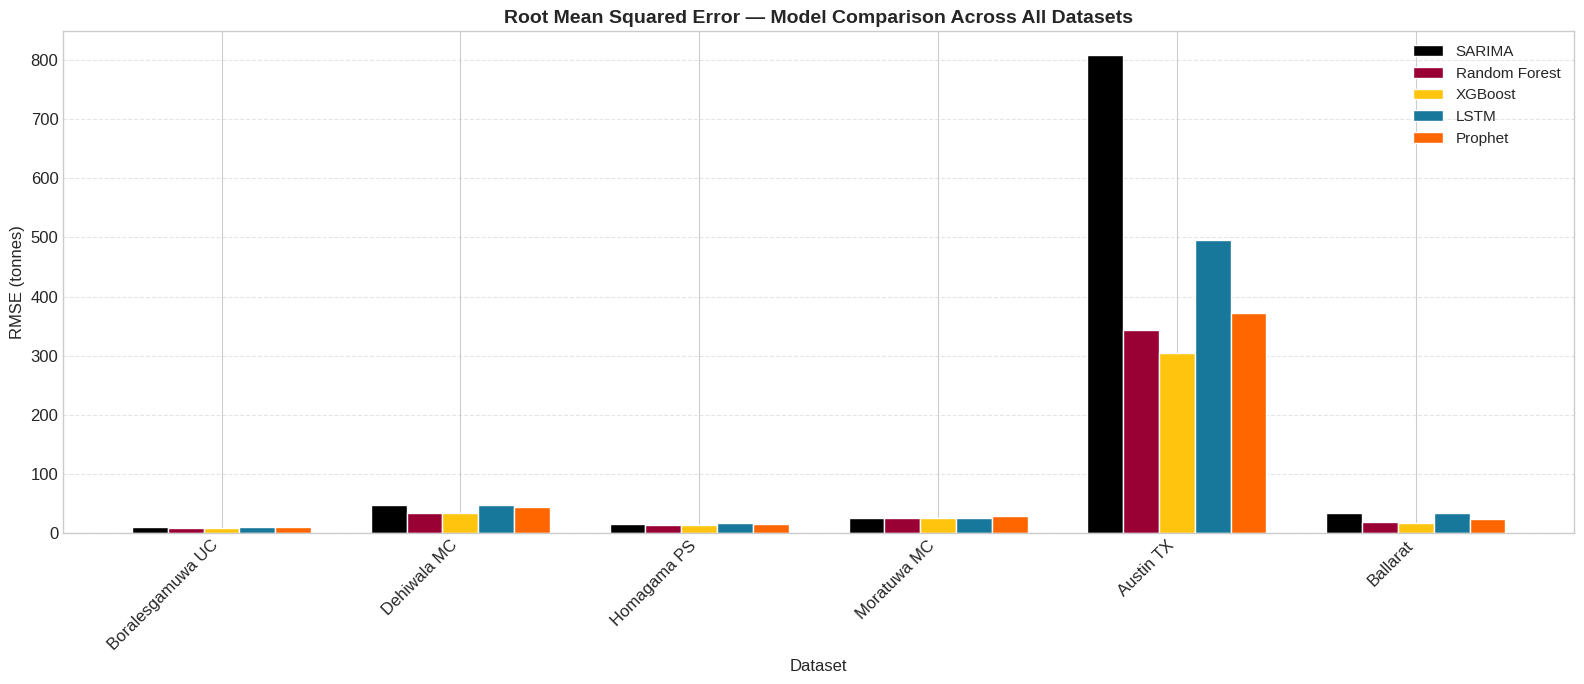

In [8]:
# --- Plot RMSE Comparison ---
fig, ax = plt.subplots(figsize=(16, 7))

bars1 = ax.bar(x - 2*width, sarima_df['rmse'], width, label='SARIMA', color='#000000', edgecolor='white')
bars2 = ax.bar(x - width, rf_df['rmse'], width, label='Random Forest', color='#990033', edgecolor='white')
bars3 = ax.bar(x, xgb_df['rmse'], width, label='XGBoost', color='#FFC50E', edgecolor='white')
bars4 = ax.bar(x + width, lstm_df['rmse'], width, label='LSTM', color='#17789C', edgecolor='white')
bars5 = ax.bar(x + 2*width, prophet_df['rmse'], width, label='Prophet', color='#FF6600', edgecolor='white')

ax.set_xlabel('Dataset', fontsize=12)
ax.set_ylabel('RMSE (tonnes)', fontsize=12)
ax.set_title('Root Mean Squared Error — Model Comparison Across All Datasets',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, 'comparison_rmse_all.png'), dpi=150, bbox_inches='tight')
plt.show()

## MAPE Comparison

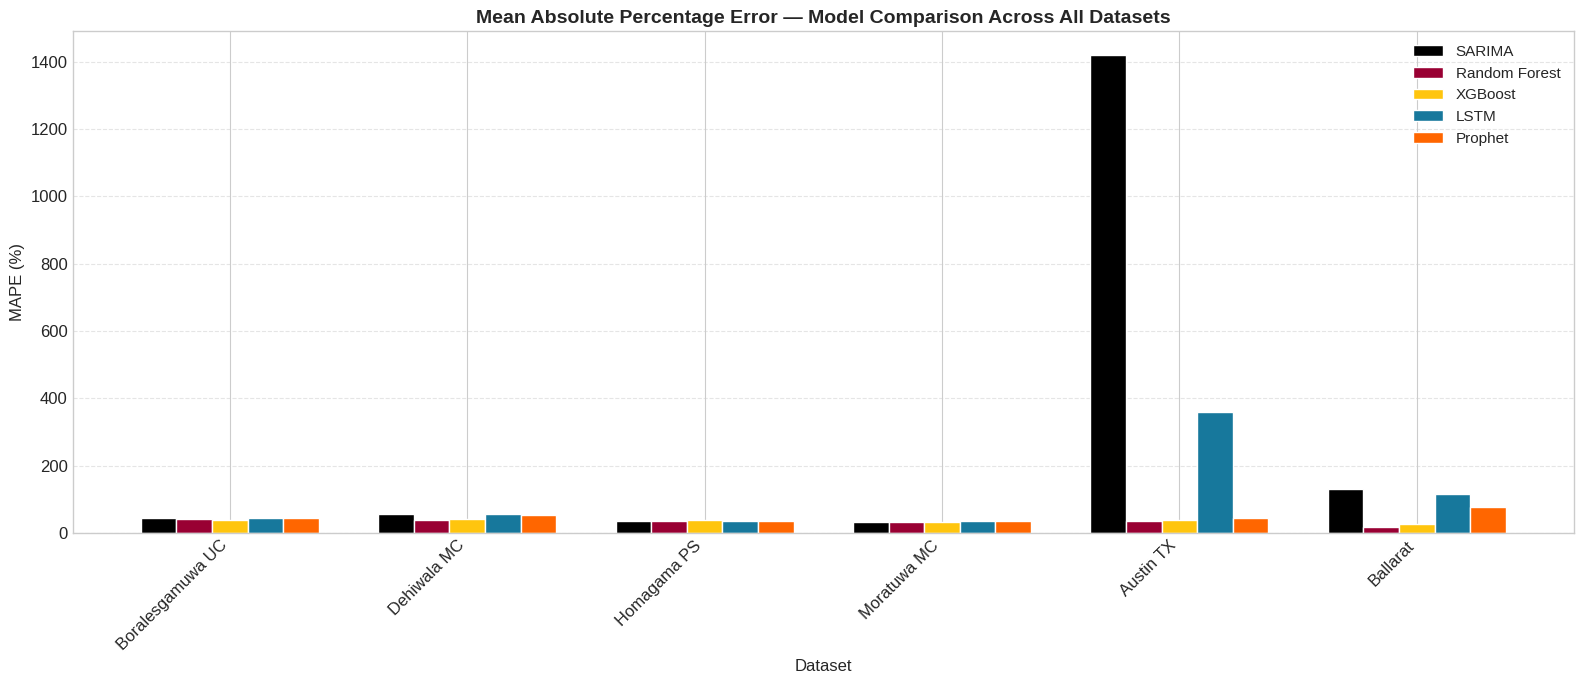

In [9]:
# --- Plot MAPE Comparison ---
fig, ax = plt.subplots(figsize=(16, 7))

bars1 = ax.bar(x - 2*width, sarima_df['mape'], width, label='SARIMA', color='#000000', edgecolor='white')
bars2 = ax.bar(x - width, rf_df['mape'], width, label='Random Forest', color='#990033', edgecolor='white')
bars3 = ax.bar(x, xgb_df['mape'], width, label='XGBoost', color='#FFC50E', edgecolor='white')
bars4 = ax.bar(x + width, lstm_df['mape'], width, label='LSTM', color='#17789C', edgecolor='white')
bars5 = ax.bar(x + 2*width, prophet_df['mape'], width, label='Prophet', color='#FF6600', edgecolor='white')

ax.set_xlabel('Dataset', fontsize=12)
ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_title('Mean Absolute Percentage Error — Model Comparison Across All Datasets',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, 'comparison_mape_all.png'), dpi=150, bbox_inches='tight')
plt.show()

# Models improvement over SARIMA (MAE)


IMPROVEMENT OVER SARIMA BASELINE (MAE)

Dataset                        |  RF vs SARIMA |  XGB vs SARIMA |  LSTM vs SARIMA |  Prophet vs SARIMA
----------------------------------------------------------------------------------------------------
Boralesgamuwa UC (Sri Lanka)   |       +17.3% |        +18.8% |          -8.5% |             -3.9%
Dehiwala MC (Sri Lanka)        |       +42.3% |        +42.2% |          -2.4% |            +14.9%
Homagama PS (Sri Lanka)        |        +3.7% |         +1.1% |         -10.4% |             -6.5%
Moratuwa MC (Sri Lanka)        |        -1.5% |         -3.5% |          -4.0% |            -26.7%
Austin TX (USA)                |       +75.6% |        +78.4% |         +49.7% |            +68.2%
Ballarat (Australia)           |       +57.8% |        +57.6% |         -10.4% |            +31.8%
----------------------------------------------------------------------------------------------------
AVERAGE                        |       +32.5% |        +32.4

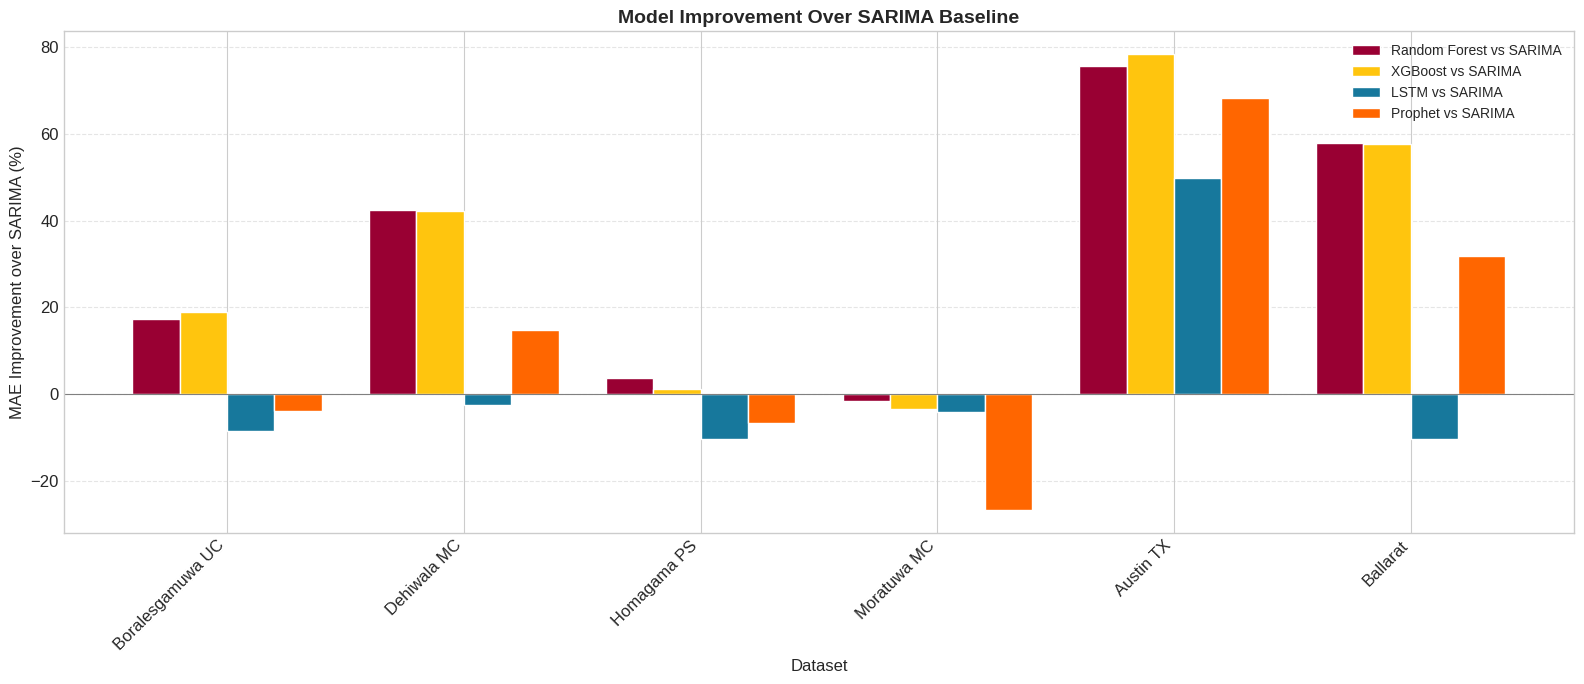

In [10]:
print("\n" + "=" * 100)
print("IMPROVEMENT OVER SARIMA BASELINE (MAE)")
print("=" * 100)

comparison = sarima_df[['dataset', 'mae']].rename(columns={'mae': 'sarima_mae'})
comparison = comparison.merge(rf_df[['dataset', 'mae']].rename(columns={'mae': 'rf_mae'}), on='dataset')
comparison = comparison.merge(xgb_df[['dataset', 'mae']].rename(columns={'mae': 'xgb_mae'}), on='dataset')
comparison = comparison.merge(lstm_df[['dataset', 'mae']].rename(columns={'mae': 'lstm_mae'}), on='dataset')
comparison = comparison.merge(prophet_df[['dataset', 'mae']].rename(columns={'mae': 'prophet_mae'}), on='dataset')

comparison['rf_improvement'] = (comparison['sarima_mae'] - comparison['rf_mae']) / comparison['sarima_mae'] * 100
comparison['xgb_improvement'] = (comparison['sarima_mae'] - comparison['xgb_mae']) / comparison['sarima_mae'] * 100
comparison['lstm_improvement'] = (comparison['sarima_mae'] - comparison['lstm_mae']) / comparison['sarima_mae'] * 100
comparison['prophet_improvement'] = (comparison['sarima_mae'] - comparison['prophet_mae']) / comparison['sarima_mae'] * 100

print(f"\n{'Dataset':<30s} | {'RF vs SARIMA':>13s} | {'XGB vs SARIMA':>14s} | {'LSTM vs SARIMA':>15s} | {'Prophet vs SARIMA':>18s}")
print("-" * 100)
for _, row in comparison.iterrows():
    print(f"{row['dataset']:<30s} | {row['rf_improvement']:>+11.1f}% | {row['xgb_improvement']:>+12.1f}% | {row['lstm_improvement']:>+13.1f}% | {row['prophet_improvement']:>+16.1f}%")

print("-" * 100)
avg_rf = comparison['rf_improvement'].mean()
avg_xgb = comparison['xgb_improvement'].mean()
avg_lstm = comparison['lstm_improvement'].mean()
avg_prophet = comparison['prophet_improvement'].mean()
print(f"{'AVERAGE':<30s} | {avg_rf:>+11.1f}% | {avg_xgb:>+12.1f}% | {avg_lstm:>+13.1f}% | {avg_prophet:>+16.1f}%")

# --- Plot: Improvement over SARIMA baseline ---
fig, ax = plt.subplots(figsize=(16, 7))

short_names = [d.split('(')[0].strip() for d in comparison['dataset']]
x = np.arange(len(comparison))
width = 0.2

ax.bar(x - 1.5*width, comparison['rf_improvement'], width,
       label='Random Forest vs SARIMA', color='#990033', edgecolor='white')
ax.bar(x - 0.5*width, comparison['xgb_improvement'], width,
       label='XGBoost vs SARIMA', color='#FFC50E', edgecolor='white')
ax.bar(x + 0.5*width, comparison['lstm_improvement'], width,
       label='LSTM vs SARIMA', color='#17789C', edgecolor='white')
ax.bar(x + 1.5*width, comparison['prophet_improvement'], width,
       label='Prophet vs SARIMA', color='#FF6600', edgecolor='white')

ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
ax.set_xlabel('Dataset')
ax.set_ylabel('MAE Improvement over SARIMA (%)')
ax.set_title('Model Improvement Over SARIMA Baseline', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, 'comparison_improvement_over_sarima.png'), dpi=150, bbox_inches='tight')
plt.show()

# Final Model Ranking

In [11]:
print("\n" + "=" * 100)
print("FINAL MODEL RANKING")
print("=" * 100)

# wins on ds per model
mae_pivot = all_results.pivot(index='dataset', columns='model', values='mae')
wins = mae_pivot.idxmin(axis=1).value_counts()

print("\nDataset wins (lowest MAE):")
for model, count in wins.items():
    print(f"  {model}: {count}/{len(mae_pivot)} datasets")

print(f"""
SUMMARY:
  - Best overall model:      {summary['mae'].idxmin()} (lowest average MAE: {summary['mae'].min():.2f}t)
  - Best individual result:  {all_results.loc[all_results['mae'].idxmin(), 'model']} on {all_results.loc[all_results['mae'].idxmin(), 'dataset']} (MAE: {all_results['mae'].min():.2f}t)
  - SARIMA baseline avg MAE: {summary.loc['SARIMA', 'mae']:.2f}t
  - RF avg improvement:      {avg_rf:+.1f}% over SARIMA
  - XGBoost avg improvement: {avg_xgb:+.1f}% over SARIMA
  - LSTM avg improvement:    {avg_lstm:+.1f}% over SARIMA
  - Prophet avg improvement: {avg_prophet:+.1f}% over SARIMA

MODEL RANKING (by average MAE):
  1. {summary['mae'].sort_values().index[0]:<20s} {summary['mae'].sort_values().values[0]:.2f}t
  2. {summary['mae'].sort_values().index[1]:<20s} {summary['mae'].sort_values().values[1]:.2f}t
  3. {summary['mae'].sort_values().index[2]:<20s} {summary['mae'].sort_values().values[2]:.2f}t
  4. {summary['mae'].sort_values().index[3]:<20s} {summary['mae'].sort_values().values[3]:.2f}t
  5. {summary['mae'].sort_values().index[4]:<20s} {summary['mae'].sort_values().values[4]:.2f}t

CONCLUSION:
  Tree-based ensemble models (XGBoost, Random Forest) with engineered
  features consistently outperformed all other approaches across all
  datasets. XGBoost achieved the lowest average MAE ({summary.loc['XGBoost','mae']:.2f}t) and
  RMSE ({summary.loc['XGBoost','rmse']:.2f}t), while Random Forest achieved the lowest
  average MAPE ({summary.loc['RF','mape']:.2f}%) and won MAE on 4 out of 6 individual
  datasets — notably without any hyperparameter optimization.

  The classical SARIMA model and deep learning LSTM both struggled to
  capture the high day-to-day variability in waste generation, with
  LSTM performing worse than expected due to limited dataset sizes.
  Prophet performed moderately, benefiting from built-in seasonality
  but lacking the predictive power of lag-based feature engineering.

  These results suggest that for daily municipal waste prediction,
  well-crafted feature engineering (lag values, rolling statistics,
  calendar and meteorological data) is more impactful than model
  complexity or automatic pattern extraction.
""")

# save results
all_results.to_csv(os.path.join(RES_DIR, 'all_models_comparison.csv'), index=False)
comparison.to_csv(os.path.join(RES_DIR, 'improvement_over_sarima.csv'), index=False)
print(f"\nAll results saved to {RES_DIR}")


FINAL MODEL RANKING

Dataset wins (lowest MAE):
  RF: 3/6 datasets
  XGBoost: 2/6 datasets
  SARIMA: 1/6 datasets

SUMMARY:
  - Best overall model:      XGBoost (lowest average MAE: 34.89t)
  - Best individual result:  XGBoost on Boralesgamuwa UC (Sri Lanka) (MAE: 5.90t)
  - SARIMA baseline avg MAE: 123.66t
  - RF avg improvement:      +32.5% over SARIMA
  - XGBoost avg improvement: +32.4% over SARIMA
  - LSTM avg improvement:    +2.3% over SARIMA
  - Prophet avg improvement: +13.0% over SARIMA

MODEL RANKING (by average MAE):
  1. XGBoost              34.89t
  2. RF                   37.68t
  3. Prophet              49.77t
  4. LSTM                 71.76t
  5. SARIMA               123.66t

CONCLUSION:
  Tree-based ensemble models (XGBoost, Random Forest) with engineered
  features consistently outperformed all other approaches across all 
  datasets. XGBoost achieved the lowest average MAE (34.89t) and 
  RMSE (67.05t), while Random Forest achieved the lowest 
  average MAPE (33.55%)